<div style="background:#1F3864; border-radius:8px; padding:22px 26px; margin-bottom:12px; font-family:Arial,sans-serif;">
  <h2 style="color:#FFFFFF; margin:0 0 8px 0; font-size:18pt;">Mapping the Cancer Research Attention Gap Using Unsupervised Learning</h2>
  <p style="margin:3px 0; font-size:11pt; color:#BBCDE5;"><b>Course:</b> APANPS5205 — Applied Analytics Frameworks and Methods II</p>
  <p style="margin:3px 0; font-size:11pt; color:#BBCDE5;"><b>Notebook:</b> 03_FINAL_ANALYSIS.ipynb</p>
  <p style="margin:8px 0 3px 0; font-size:11pt; color:#BBCDE5;"><b>Group 2 Members:</b>
  Farzana Khan Moutushi &nbsp;|&nbsp; Claudia Orisakwe &nbsp;|&nbsp; Simran Chawla &nbsp;|&nbsp; Wen Jiang</p>
  <p style="margin:12px 0 4px 0; font-size:11pt; color:#DDEBFF;"><b>Purpose:</b><br>
  This is the <b>final analysis notebook</b> for the project. It presents only the analyses
  selected for the final report, each of which directly addresses the central research question:
  <b><i>Are cancer research resources aligned with the burden of disease?</i></b>
  Exploratory attempts and methods not carried forward are documented in the working notebook
  (02_WORKING_ANALYSIS_ALL_ATTEMPTS.ipynb).</p>
</div>

---

<div style="background:#F0F4FA; border-left:5px solid #2E75B6; border-radius:6px; padding:16px 20px; margin-bottom:10px; font-family:Arial,sans-serif; font-size:11pt;">
<b>Executive Analysis Summary</b><br><br>

| | |
|---|---|
| <b>Research question</b> | Are cancer research resources aligned with the burden of disease? |
| <b>Unit of analysis</b> | Cancer type (16 cancer types, 2019–2023) |
| <b>Primary metric</b> | Composite Attention Gap Score (Burden Score − Research Attention Score) |
| <b>Supporting methods</b> | Component-level gap checks; K-means clustering (k = 3); TF-IDF theme exploration (if text available) |
| <b>Data sources</b> | SEER Cancer Stat Facts, ClinicalTrials.gov, PubMed/NCBI |
| <b>Output</b> | Ranked summary tables, decision-maker review table, cluster profiles, charts |

<br>
<b>Key finding:</b> Brain Cancer (+0.33) and Non-Hodgkin Lymphoma (+0.29) show the largest
positive Attention Gap Scores, indicating that their disease burden appears less commensurate
with their measured research attention than any other cancer type in this dataset. Both are
assigned the highest-priority review designation. Prostate Cancer (+0.18) and Kidney Cancer
(+0.15) are moderately under-attended. Lung Cancer, Pancreatic Cancer, and several others
fall in the relatively balanced or higher-attention range. At the opposite end of the
distribution, Thyroid Cancer (−0.29), Bladder Cancer (−0.29), and Leukemia (−0.29) show
research attention that meets or exceeds their measured burden.
</div>

---
## 1. Project Setup

This section defines all project paths, imports the required libraries, and configures
display and chart settings. All outputs — processed tables and charts — are saved to the
appropriate project subfolders for inclusion in the final report.

In [ ]:
# ============================================================
# 1. Project Setup
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# ── Mount Google Drive ──────────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)
    DRIVE_ROOT = Path("/content/drive/MyDrive")
except Exception:
    DRIVE_ROOT = Path.home()

# ── Locate project folder ───────────────────────────────────────────────────
PROJECT_FOLDER_NAME = "Cancer_Research_Attention_Gap_Final"
PROJECT_DIR = DRIVE_ROOT / PROJECT_FOLDER_NAME

if not PROJECT_DIR.exists():
    matches = list(DRIVE_ROOT.rglob(PROJECT_FOLDER_NAME))
    if matches:
        PROJECT_DIR = matches[0]
    else:
        raise FileNotFoundError(
            f"Project folder '{PROJECT_FOLDER_NAME}' not found in Google Drive. "
            "Add the shared folder as a shortcut to My Drive."
        )

# ── Define subfolders ───────────────────────────────────────────────────────
CLEAN_DIR      = PROJECT_DIR / "01 Data" / "Cleaned Data"
PROCESSED_DIR  = PROJECT_DIR / "01 Data" / "Processed Analysis Data"
FINAL_CODE_DIR = PROJECT_DIR / "03 Final Python Code"
CHART_DIR      = PROJECT_DIR / "04 Output Files" / "Charts"
TABLE_DIR      = PROJECT_DIR / "04 Output Files" / "Tables"
REPORT_DIR     = PROJECT_DIR / "05 Final Report"

for folder in [PROCESSED_DIR, CHART_DIR, TABLE_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# ── Display settings ────────────────────────────────────────────────────────
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Project setup complete.")
print(f"  PROJECT_DIR  : {PROJECT_DIR}")
print(f"  CLEAN_DIR    : {CLEAN_DIR}")
print(f"  CHART_DIR    : {CHART_DIR}")
print(f"  TABLE_DIR    : {TABLE_DIR}")


Mounted at /content/drive
Project setup complete.
  PROJECT_DIR  : /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final
  CLEAN_DIR    : /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/01 Data/Cleaned Data
  CHART_DIR    : /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts
  TABLE_DIR    : /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Tables


---
## 2. Load Cleaned Data

The cleaned dataset (`cancer_attention_gap_clean.csv`) contains 80 cancer-year observations:
16 cancer types × 5 years (2019–2023). This section loads the file, confirms its structure,
and documents any missing values before the analysis proceeds. Verifying data completeness
at this stage ensures that subsequent calculations and rankings are reproducible and reliable.

In [ ]:
# ============================================================
# 2. Load Cleaned Dataset
# ============================================================

clean_file = CLEAN_DIR / "cancer_attention_gap_clean.csv"

if not clean_file.exists():
    raise FileNotFoundError(f"Cleaned data file not found at: {clean_file}")

df = pd.read_csv(clean_file)

print(f"File loaded: {clean_file}")
print(f"Shape       : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Years       : {sorted(df['year'].unique())}")
print(f"Cancer types ({df['cancer_type'].nunique()}):")
for ct in sorted(df["cancer_type"].unique()):
    print(f"  - {ct}")

print("\nMissing values (columns with at least 1 missing):")
missing = df.isna().sum()
missing = missing[missing > 0]
print(missing.to_string() if len(missing) else "  None found.")

print("\nFirst 5 rows:")
display(df.head())


File loaded: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/01 Data/Cleaned Data/cancer_attention_gap_clean.csv
Shape       : 80 rows × 23 columns
Years       : [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Cancer types (16):
  - Bladder Cancer
  - Brain Cancer
  - Breast Cancer
  - Colorectal Cancer
  - Hodgkin Lymphoma
  - Kidney Cancer
  - Leukemia
  - Liver Cancer
  - Lung Cancer
  - Melanoma
  - Non-Hodgkin Lymphoma
  - Ovarian Cancer
  - Pancreatic Cancer
  - Prostate Cancer
  - Stomach Cancer
  - Thyroid Cancer

Missing values (columns with at least 1 missing):
publication_text_sample     3
publication_title_sample    3
journal_sample              3

First 5 rows:


,cancer_type,year,incidence_rate,incidence_value_source,mortality_rate,five_year_survival_rate,survival_value_source,source,source_url,trial_count,active_trial_count,phase_1_count,phase_2_count,phase_3_count,trial_text_sample,publication_count,publication_text_sample,publication_title_sample,journal_sample,trial_to_mortality_ratio,publication_to_mortality_ratio,attention_gap_score,combined_text_sample
0,Breast Cancer,2019,135.690,SEER 12 observed,19.750,93.300,Modeled trend,SEER Cancer Stat Facts,https://seer.cancer.gov/statfacts/html/breast....,12,4,0,3,2,Breast cancer patients who received docetaxel ...,19987,Early breast cancer: ESMO Clinical Practice Gu...,Early breast cancer: ESMO Clinical Practice Gu...,Annals of oncology : official journal of the E...,0.608,"1,012.000",0.378,Breast cancer patients who received docetaxel ...
1,Breast Cancer,2020,122.100,SEER 12 observed,19.450,93.440,Modeled trend,SEER Cancer Stat Facts,https://seer.cancer.gov/statfacts/html/breast....,20,4,4,7,0,"Recently, there is growing interest in the app...",22807,"Breast cancer: Biology, biomarkers, and treatm...","Breast cancer: Biology, biomarkers, and treatm...",International immunopharmacology | Cancer cell...,1.028,"1,172.596",0.047,"Recently, there is growing interest in the app..."
2,Breast Cancer,2021,139.390,SEER 12 observed,19.220,93.560,Modeled trend,SEER Cancer Stat Facts,https://seer.cancer.gov/statfacts/html/breast....,17,6,3,2,1,The purpose of this study is to investigate th...,24442,Breast Surgery: Management of Postoperative Co...,Breast Surgery: Management of Postoperative Co...,The Surgical clinics of North America | Annals...,0.884,"1,271.696",0.119,The purpose of this study is to investigate th...
3,Breast Cancer,2022,136.080,SEER 12 observed,18.860,93.690,Modeled trend,SEER Cancer Stat Facts,https://seer.cancer.gov/statfacts/html/breast....,18,6,5,5,0,"In this study, a randomized controlled study w...",24185,"Breast cancer: presentation, investigation and...","Breast cancer: presentation, investigation and...","British journal of hospital medicine (London, ...",0.954,"1,282.344",0.041,"In this study, a randomized controlled study w..."
4,Breast Cancer,2023,136.500,SEER 12 observed,18.500,93.810,Modeled trend,SEER Cancer Stat Facts,https://seer.cancer.gov/statfacts/html/breast....,14,7,4,0,3,"This is a multicentre, multinational Phase Ib ...",23873,Molecular Classification of Breast Cancer. Bre...,Molecular Classification of Breast Cancer. | E...,PET clinics | Annals of oncology : official jo...,0.757,"1,290.432",0.162,"This is a multicentre, multinational Phase Ib ..."


---
## 3. Create Cancer-Level Analysis Dataset

The raw dataset is structured at the cancer-year level, with one row per cancer type per year.
To enable direct comparison across cancer types, rate-based variables are averaged across
2019–2023 and count-based variables are summed. The result is a **16-row cancer-level dataset**
that serves as the basis for all metrics, charts, and clustering in this analysis.

Aggregating to the cancer-type level is a judicious design choice: it smooths year-to-year
variation in publication and trial counts while preserving the distributional differences
between cancer types that are central to the research question.

In [ ]:
# ============================================================
# 3. Aggregate to Cancer-Level Dataset
# ============================================================

optional_text_cols = ["combined_text_sample", "trial_text_sample", "publication_text_sample"]
available_text_cols = [c for c in optional_text_cols if c in df.columns]

def first_non_null(series):
    non_null = series.dropna()
    return non_null.iloc[0] if len(non_null) else ""

agg_dict = {
    "incidence_rate":        "mean",
    "mortality_rate":        "mean",
    "five_year_survival_rate": "mean",
    "trial_count":           "sum",
    "active_trial_count":    "sum",
    "publication_count":     "sum",
    "phase_1_count":         "sum",
    "phase_2_count":         "sum",
    "phase_3_count":         "sum",
}
agg_dict = {k: v for k, v in agg_dict.items() if k in df.columns}

analysis_df = df.groupby("cancer_type").agg(agg_dict).reset_index()

analysis_df = analysis_df.rename(columns={
    "incidence_rate":          "avg_incidence_rate",
    "mortality_rate":          "avg_mortality_rate",
    "five_year_survival_rate": "avg_five_year_survival_rate",
    "trial_count":             "total_trial_count",
    "active_trial_count":      "total_active_trial_count",
    "publication_count":       "total_publication_count",
    "phase_1_count":           "total_phase_1_count",
    "phase_2_count":           "total_phase_2_count",
    "phase_3_count":           "total_phase_3_count",
})

for col in available_text_cols:
    samples = df.groupby("cancer_type")[col].apply(first_non_null).reset_index()
    analysis_df = analysis_df.merge(samples, on="cancer_type", how="left")

# Save base table
base_path = PROCESSED_DIR / "cancer_attention_gap_analysis_ready.csv"
analysis_df.to_csv(base_path, index=False)

print(f"Cancer-level dataset: {analysis_df.shape[0]} rows × {analysis_df.shape[1]} columns")
print(f"Saved: {base_path}")
display(analysis_df[["cancer_type","avg_incidence_rate","avg_mortality_rate",
                      "avg_five_year_survival_rate","total_trial_count","total_publication_count"]])


Cancer-level dataset: 16 rows × 13 columns
Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/01 Data/Processed Analysis Data/cancer_attention_gap_analysis_ready.csv


,cancer_type,avg_incidence_rate,avg_mortality_rate,avg_five_year_survival_rate,total_trial_count,total_publication_count
0,Bladder Cancer,17.054,4.140,80.020,97,15866
1,Brain Cancer,5.848,4.398,34.740,71,2383
2,Breast Cancer,133.952,19.156,93.560,81,115294
3,Colorectal Cancer,35.224,12.858,68.168,82,55062
4,Hodgkin Lymphoma,2.400,0.256,92.314,75,7802
5,Kidney Cancer,15.648,3.440,81.890,77,3159
6,Leukemia,14.064,5.844,72.166,88,51522
7,Liver Cancer,8.942,6.622,23.732,87,14897
8,Lung Cancer,40.012,31.538,34.478,92,79441
9,Melanoma,24.014,2.020,96.558,80,38542


---
## 4. Composite Attention Gap Score

The Composite Attention Gap Score is the primary metric for this analysis. It provides a
single, interpretable measure of whether a cancer type's disease burden is commensurate with
its measured research attention.

**Construction:**

| Component | Variables | Direction |
|---|---|---|
| **Burden Score** | Incidence rate, Mortality rate, (1 − Five-year survival rate) | Higher burden → higher score |
| **Research Attention Score** | Total publications, Total clinical trials | More attention → higher score |
| **Attention Gap Score** | Burden Score − Research Attention Score | Positive = burden exceeds attention |

All input variables are converted to percentile ranks (0–1) before averaging, ensuring that
no single variable dominates due to differences in scale or unit. Scores are relative — they
reflect each cancer type's position within this 16-cancer dataset, not an absolute judgment
of research sufficiency.

**Interpretation:**
- **Positive score (≥ 0.20):** Disease burden substantially exceeds research attention — warrants closer review.
- **Positive score (0.05 to 0.19):** Burden moderately exceeds attention — medium-priority review.
- **Near zero (−0.05 to +0.05):** Burden and attention are broadly aligned.
- **Negative score (< −0.05):** Research attention meets or exceeds measured burden.

In [ ]:
# ============================================================
# 4. Composite Attention Gap Score
# ============================================================

# ── Burden Score ────────────────────────────────────────────────────────────
mortality_pct    = analysis_df["avg_mortality_rate"].rank(pct=True)
incidence_pct    = analysis_df["avg_incidence_rate"].rank(pct=True)
low_survival_pct = 1 - analysis_df["avg_five_year_survival_rate"].rank(pct=True)

analysis_df["burden_score"] = (mortality_pct + incidence_pct + low_survival_pct) / 3

# ── Research Attention Score ────────────────────────────────────────────────
publication_pct = analysis_df["total_publication_count"].rank(pct=True)
trial_pct       = analysis_df["total_trial_count"].rank(pct=True)

analysis_df["research_attention_score"] = (publication_pct + trial_pct) / 2

# ── Attention Gap Score ─────────────────────────────────────────────────────
analysis_df["attention_gap_score"] = (
    analysis_df["burden_score"] - analysis_df["research_attention_score"]
)

def categorize_gap(score):
    if score >= 0.20:
        return "Potentially under-attended"
    elif score >= 0.05:
        return "Moderately under-attended"
    elif score > -0.05:
        return "Relatively balanced"
    else:
        return "Higher research attention"

analysis_df["attention_category"] = analysis_df["attention_gap_score"].apply(categorize_gap)

# ── Supporting ratio metrics ────────────────────────────────────────────────
analysis_df["publication_to_mortality_ratio"] = (
    analysis_df["total_publication_count"] / analysis_df["avg_mortality_rate"]
)
analysis_df["trial_to_mortality_ratio"] = (
    analysis_df["total_trial_count"] / analysis_df["avg_mortality_rate"]
)

# ── Display ranked summary ──────────────────────────────────────────────────
ranked_summary = analysis_df[[
    "cancer_type", "avg_incidence_rate", "avg_mortality_rate",
    "avg_five_year_survival_rate", "total_trial_count", "total_publication_count",
    "burden_score", "research_attention_score", "attention_gap_score", "attention_category"
]].sort_values("attention_gap_score", ascending=False).reset_index(drop=True)

display(ranked_summary)

# ── Save ranked summary ─────────────────────────────────────────────────────
ranked_path = TABLE_DIR / "attention_gap_ranked_summary.csv"
ranked_summary.to_csv(ranked_path, index=False)
print(f"Saved: {ranked_path}")


,cancer_type,avg_incidence_rate,avg_mortality_rate,avg_five_year_survival_rate,total_trial_count,total_publication_count,burden_score,research_attention_score,attention_gap_score,attention_category
0,Brain Cancer,5.848,4.398,34.740,71,2383,0.438,0.109,0.328,Potentially under-attended
1,Non-Hodgkin Lymphoma,18.690,4.920,74.346,76,4643,0.542,0.250,0.292,Potentially under-attended
2,Prostate Cancer,117.876,19.108,99.020,71,48407,0.604,0.422,0.182,Moderately under-attended
3,Kidney Cancer,15.648,3.440,81.890,77,3159,0.396,0.250,0.146,Moderately under-attended
4,Liver Cancer,8.942,6.622,23.732,87,14897,0.604,0.578,0.026,Relatively balanced
5,Ovarian Cancer,10.306,5.888,54.816,78,22755,0.521,0.500,0.021,Relatively balanced
6,Colorectal Cancer,35.224,12.858,68.168,82,55062,0.729,0.719,0.010,Relatively balanced
7,Lung Cancer,40.012,31.538,34.478,92,79441,0.896,0.906,-0.010,Relatively balanced
8,Stomach Cancer,7.572,2.704,45.406,87,1213,0.375,0.391,-0.016,Relatively balanced
9,Breast Cancer,133.952,19.156,93.560,81,115294,0.708,0.750,-0.042,Relatively balanced


Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Tables/attention_gap_ranked_summary.csv


---
## 5. Component-Level Attention Gap Checks

The Composite Attention Gap Score combines incidence, mortality, and five-year survival into
a single burden measure. To assess whether the composite findings are robust across individual
burden definitions — and to discern the nature of each gap — this section computes separate
attention gaps for each burden component.

**How to interpret the component table:**

- A cancer type showing positive gaps across **all three** components provides the most robust
  signal: its burden exceeds research attention regardless of how burden is defined. Such
  cross-component consistency offers stronger preliminary evidence of possible misalignment.
- A positive gap on **one or two** components may still warrant review; however, the driver
  of the gap — whether volume-based (incidence) or severity-based (mortality, survival) —
  should inform how decision-makers interpret and act on the finding.
- **Brain Cancer** shows positive gaps on both the mortality (+0.33) and survival (+0.64)
  components, reflecting its poor five-year survival rate (34.7%). Its incidence component
  gap is near zero, indicating that the gap is driven by severity rather than patient volume.
- **Non-Hodgkin Lymphoma** shows positive gaps across all three components — incidence (+0.44),
  mortality (+0.25), and survival (+0.19) — making it the most cross-component-consistent
  finding in this analysis. This consistency corroborates its high composite ranking.
- **Prostate Cancer** shows salient positive gaps on incidence (+0.52) and mortality (+0.45),
  but a negative survival gap (−0.42), reflecting its very high five-year survival rate (99%).
  Its composite gap is therefore driven by volume burden, not poor prognosis — a nuanced
  distinction that is decision-relevant when evaluating the nature of any potential gap.
- **Lung Cancer's** composite gap is near zero (−0.01), placing it in the relatively balanced
  category. Moreover, although it carries the highest mortality rate in the dataset
  (31.5 per 100,000), it also attracts the highest trial count (94) and publication count
  (79,441), producing a high research attention score that offsets its burden at the relative
  scale used here.

> **Note on mortality and survival:** These two burden components are conceptually related —
> cancers with high mortality rates often have low five-year survival rates. In this dataset,
> the Pearson correlation between average mortality rate and average five-year survival rate
> at the cancer-type level is approximately −0.20 (weak to moderate), confirming that the two
> components carry meaningfully different information. The composite score should nevertheless
> be read as a broad prioritization index rather than three fully independent signals.

In [ ]:
# ============================================================
# 5. Component-Level Attention Gap Checks
# ============================================================

analysis_df["incidence_burden_score"] = analysis_df["avg_incidence_rate"].rank(pct=True)
analysis_df["mortality_burden_score"] = analysis_df["avg_mortality_rate"].rank(pct=True)
analysis_df["survival_burden_score"]  = 1 - analysis_df["avg_five_year_survival_rate"].rank(pct=True)

analysis_df["incidence_attention_gap"] = (
    analysis_df["incidence_burden_score"] - analysis_df["research_attention_score"]
)
analysis_df["mortality_attention_gap"] = (
    analysis_df["mortality_burden_score"] - analysis_df["research_attention_score"]
)
analysis_df["survival_attention_gap"] = (
    analysis_df["survival_burden_score"] - analysis_df["research_attention_score"]
)

component_summary = analysis_df[[
    "cancer_type", "incidence_attention_gap", "mortality_attention_gap",
    "survival_attention_gap", "attention_gap_score", "attention_category"
]].sort_values("attention_gap_score", ascending=False).reset_index(drop=True)

display(component_summary)

comp_path = TABLE_DIR / "component_level_attention_gap_summary.csv"
component_summary.to_csv(comp_path, index=False)
print(f"Saved: {comp_path}")


,cancer_type,incidence_attention_gap,mortality_attention_gap,survival_attention_gap,attention_gap_score,attention_category
0,Brain Cancer,0.016,0.328,0.641,0.328,Potentially under-attended
1,Non-Hodgkin Lymphoma,0.438,0.250,0.188,0.292,Potentially under-attended
2,Prostate Cancer,0.516,0.453,-0.422,0.182,Moderately under-attended
3,Kidney Cancer,0.312,0.062,0.062,0.146,Moderately under-attended
4,Liver Cancer,-0.328,0.109,0.297,0.026,Relatively balanced
5,Ovarian Cancer,-0.188,0.125,0.125,0.021,Relatively balanced
6,Colorectal Cancer,0.094,0.094,-0.156,0.010,Relatively balanced
7,Lung Cancer,-0.031,0.094,-0.094,-0.010,Relatively balanced
8,Stomach Cancer,-0.203,-0.141,0.297,-0.016,Relatively balanced
9,Breast Cancer,0.250,0.188,-0.562,-0.042,Relatively balanced


Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Tables/component_level_attention_gap_summary.csv


In [ ]:
# ============================================================
# Decision-Maker Review Table
# ============================================================
# Each cancer type receives a recommended review priority based on its
# composite attention category and how consistently it shows a positive gap
# across all three burden components (incidence, mortality, survival).
# Consistency across components indicates the finding is not driven by
# a single burden definition and represents a stronger signal.

def recommended_review_priority(row):
    positive_components = sum([
        row["incidence_attention_gap"] > 0,
        row["mortality_attention_gap"]  > 0,
        row["survival_attention_gap"]   > 0,
    ])
    if row["attention_category"] == "Potentially under-attended" and positive_components >= 2:
        return "High priority for review"
    elif row["attention_category"] in ["Potentially under-attended", "Moderately under-attended"]:
        return "Medium priority for review"
    elif row["attention_category"] == "Relatively balanced":
        return "Monitor"
    else:
        return "Lower priority for review"

analysis_df["recommended_review_priority"] = analysis_df.apply(recommended_review_priority, axis=1)

review_table = analysis_df[[
    "cancer_type", "attention_gap_score",
    "incidence_attention_gap", "mortality_attention_gap", "survival_attention_gap",
    "attention_category", "recommended_review_priority"
]].sort_values("attention_gap_score", ascending=False).reset_index(drop=True)

display(review_table)

review_path = TABLE_DIR / "decision_maker_review_table.csv"
review_table.to_csv(review_path, index=False)
print(f"Saved: {review_path}")

# Re-save the full analysis dataset with all new columns
full_path = PROCESSED_DIR / "cancer_attention_gap_analysis_ready.csv"
analysis_df.to_csv(full_path, index=False)
print(f"Updated analysis-ready dataset: {full_path}")


,cancer_type,attention_gap_score,incidence_attention_gap,mortality_attention_gap,survival_attention_gap,attention_category,recommended_review_priority
0,Brain Cancer,0.328,0.016,0.328,0.641,Potentially under-attended,High priority for review
1,Non-Hodgkin Lymphoma,0.292,0.438,0.250,0.188,Potentially under-attended,High priority for review
2,Prostate Cancer,0.182,0.516,0.453,-0.422,Moderately under-attended,Medium priority for review
3,Kidney Cancer,0.146,0.312,0.062,0.062,Moderately under-attended,Medium priority for review
4,Liver Cancer,0.026,-0.328,0.109,0.297,Relatively balanced,Monitor
5,Ovarian Cancer,0.021,-0.188,0.125,0.125,Relatively balanced,Monitor
6,Colorectal Cancer,0.010,0.094,0.094,-0.156,Relatively balanced,Monitor
7,Lung Cancer,-0.010,-0.031,0.094,-0.094,Relatively balanced,Monitor
8,Stomach Cancer,-0.016,-0.203,-0.141,0.297,Relatively balanced,Monitor
9,Breast Cancer,-0.042,0.250,0.188,-0.562,Relatively balanced,Monitor


Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Tables/decision_maker_review_table.csv
Updated analysis-ready dataset: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/01 Data/Processed Analysis Data/cancer_attention_gap_analysis_ready.csv


---
## 6. Final Visualizations

The charts in this section each address the central research question from a distinct
analytical angle. Taken together, they provide a multi-perspective view of the
burden-attention relationship that is more informative than any single chart alone.
Titles and captions are written to support decision-maker interpretation without
requiring specialist statistical knowledge.

**Charts included:**
- **Chart 1:** Ranked Composite Attention Gap Score — primary results overview across all 16 cancer types.
- **Chart 2:** Component-Level Attention Gaps — assesses robustness across individual burden definitions.
- **Chart 3:** Burden Score vs. Research Attention Score scatter — visualizes proportionality relative to the alignment diagonal.
- **Chart 4:** Burden Rank vs. Attention Rank dumbbell — highlights rank reversals that are not apparent from scores alone.
- **Chart 5:** Correlation heatmap — a supporting sensitivity check confirming that trial and publication counts are largely independent indicators.

Charts are saved to: `04 Output Files / Charts`

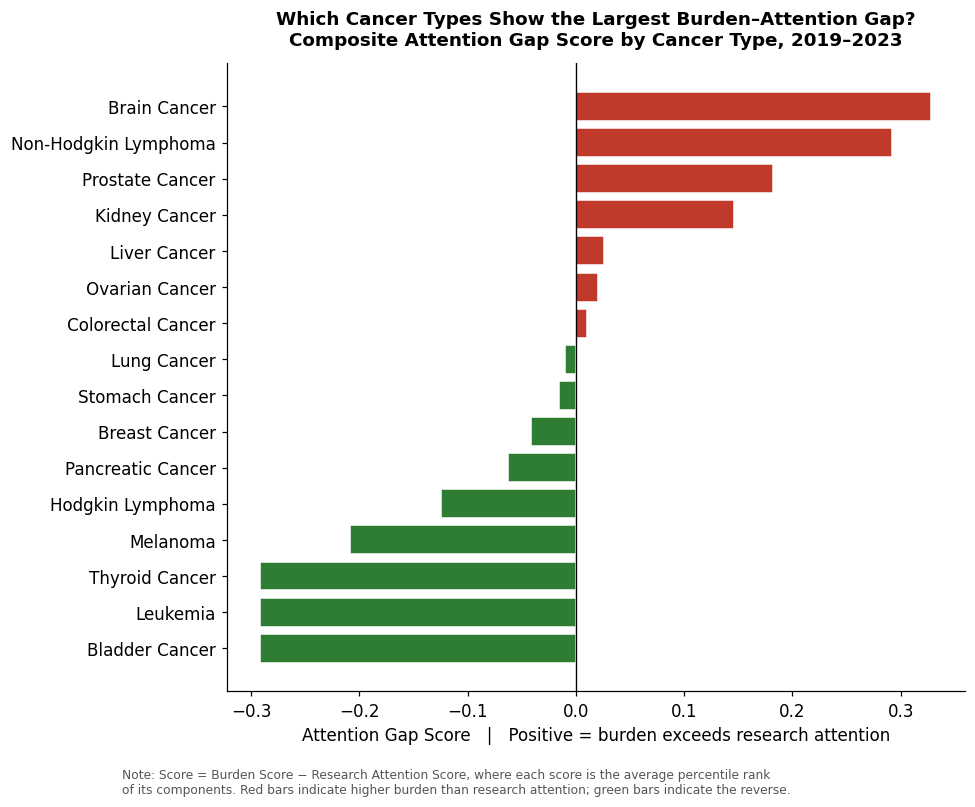

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/01_ranked_attention_gap_score.png

Decision-maker interpretation:
Cancer types with the largest positive scores (red) carry higher disease burden than
their current publication and trial activity would suggest. These warrant closer review
as possible under-attention cases. Green bars indicate research attention that meets or
exceeds measured burden.


In [ ]:
# ============================================================
# Chart 1: Ranked Composite Attention Gap Score
# ============================================================

plot_df = analysis_df.sort_values("attention_gap_score")
colors = ["#C0392B" if v > 0 else "#2E7D32" for v in plot_df["attention_gap_score"]]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(plot_df["cancer_type"], plot_df["attention_gap_score"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.9)

ax.set_title("Which Cancer Types Show the Largest Burden–Attention Gap?\n"
             "Composite Attention Gap Score by Cancer Type, 2019–2023",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Attention Gap Score   |   Positive = burden exceeds research attention")
ax.set_ylabel("")

fig.text(0.13, -0.04,
         "Note: Score = Burden Score − Research Attention Score, where each score is the "
         "average percentile rank\nof its components. Red bars indicate higher burden than "
         "research attention; green bars indicate the reverse.",
         fontsize=8, color="#555555", ha="left")

fig.tight_layout()
path = CHART_DIR / "01_ranked_attention_gap_score.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print(f"Saved: {path}")

print("\nDecision-maker interpretation:")
print("Cancer types with the largest positive scores (red) carry higher disease burden than")
print("their current publication and trial activity would suggest. These warrant closer review")
print("as possible under-attention cases. Green bars indicate research attention that meets or")
print("exceeds measured burden.")


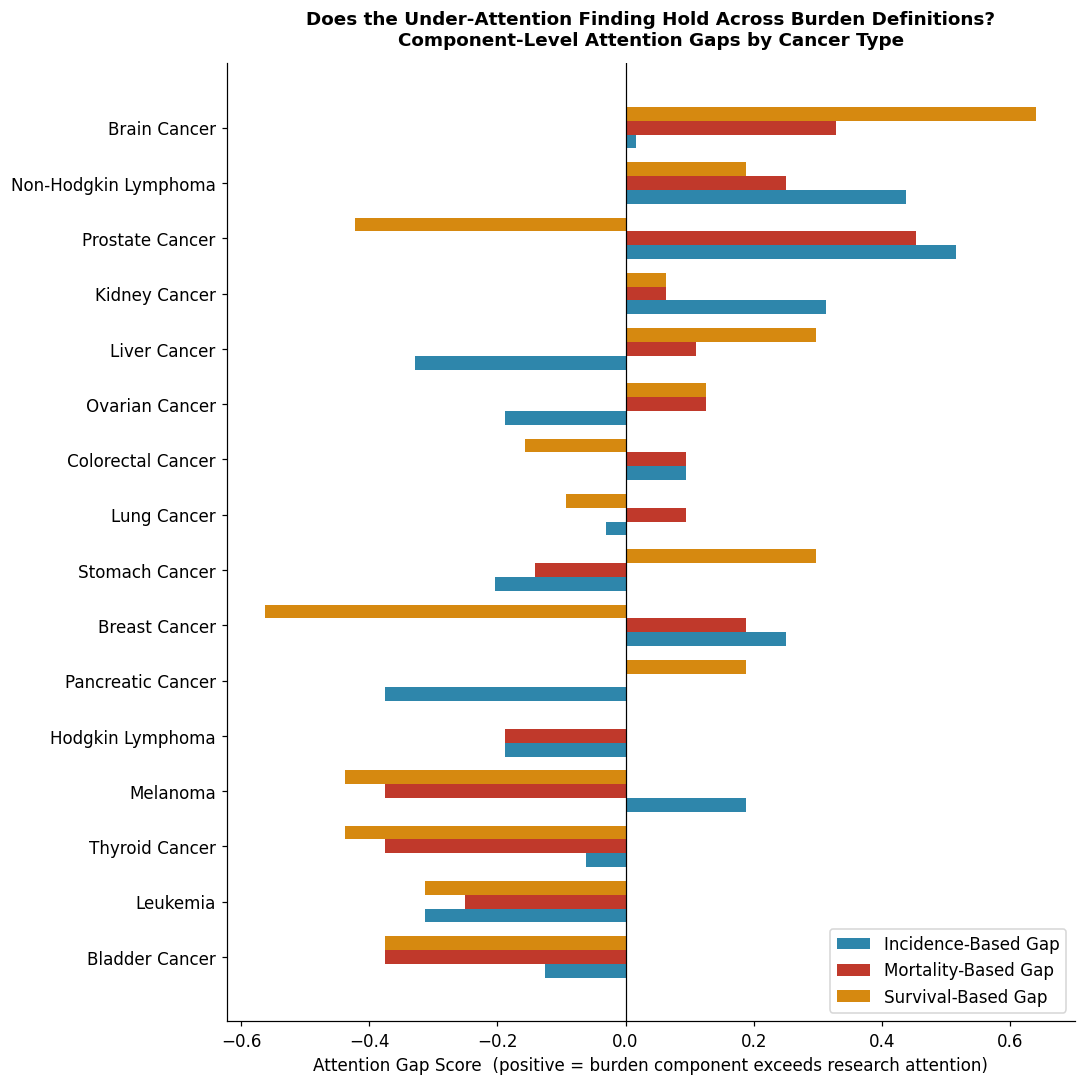

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/02_component_level_attention_gaps.png

Decision-maker interpretation:
Cancer types with consistently positive bars across all three components show a
burden-attention gap regardless of how burden is defined — a stronger signal
for closer review than a gap that appears only on one component.


In [ ]:
# ============================================================
# Chart 2: Component-Level Attention Gaps by Cancer Type
# ============================================================

plot_df = analysis_df.sort_values("attention_gap_score", ascending=True)
y_pos    = np.arange(len(plot_df))
bar_h    = 0.25

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(y_pos - bar_h, plot_df["incidence_attention_gap"], height=bar_h,
        color="#2E86AB", label="Incidence-Based Gap")
ax.barh(y_pos,         plot_df["mortality_attention_gap"],  height=bar_h,
        color="#C0392B", label="Mortality-Based Gap")
ax.barh(y_pos + bar_h, plot_df["survival_attention_gap"],  height=bar_h,
        color="#D68910", label="Survival-Based Gap")

ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["cancer_type"])
ax.set_xlabel("Attention Gap Score  (positive = burden component exceeds research attention)")
ax.set_title("Does the Under-Attention Finding Hold Across Burden Definitions?\n"
             "Component-Level Attention Gaps by Cancer Type", fontsize=12, fontweight="bold", pad=12)
ax.legend(loc="lower right")

fig.tight_layout()
path = CHART_DIR / "02_component_level_attention_gaps.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print(f"Saved: {path}")

print("\nDecision-maker interpretation:")
print("Cancer types with consistently positive bars across all three components show a")
print("burden-attention gap regardless of how burden is defined — a stronger signal")
print("for closer review than a gap that appears only on one component.")


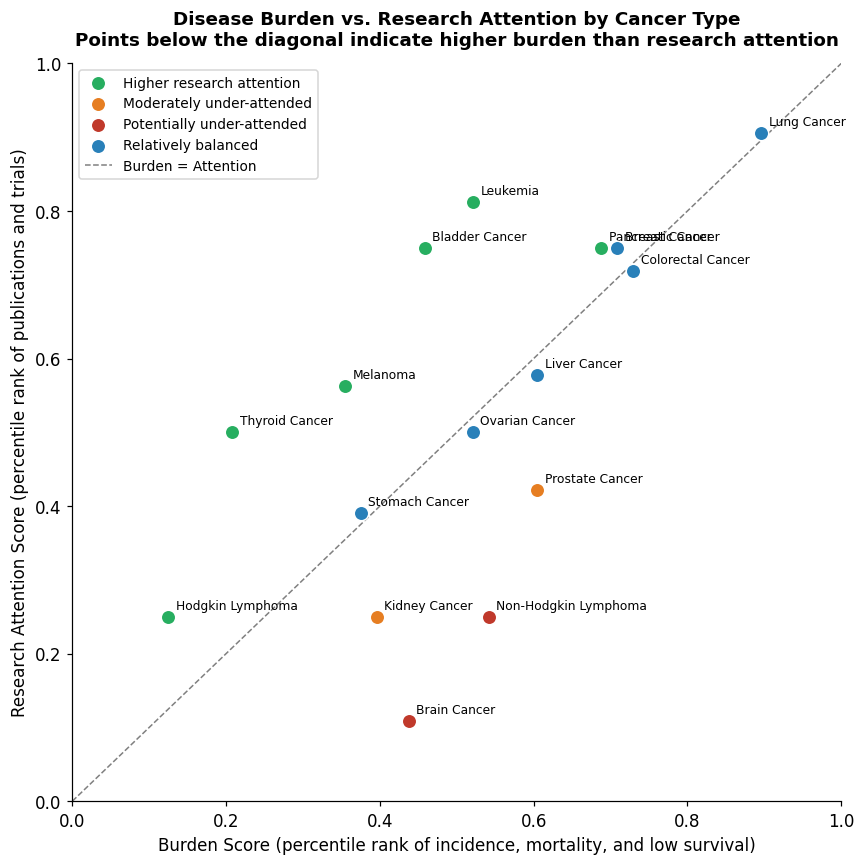

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/03_burden_vs_attention_scatter.png

Decision-maker interpretation:
Points below the dashed diagonal carry higher disease burden than their research attention
would suggest. Points above have comparatively higher research attention than their burden.


In [ ]:
# ============================================================
# Chart 3: Burden Score vs. Research Attention Score
# ============================================================

CAT_COLORS = {
    "Potentially under-attended":  "#C0392B",
    "Moderately under-attended":   "#E67E22",
    "Relatively balanced":         "#2980B9",
    "Higher research attention":   "#27AE60",
}

fig, ax = plt.subplots(figsize=(8, 8))

for cat, grp in analysis_df.groupby("attention_category"):
    ax.scatter(grp["burden_score"], grp["research_attention_score"],
               s=90, color=CAT_COLORS.get(cat, "gray"),
               edgecolor="white", zorder=3, label=cat)
    for _, row in grp.iterrows():
        ax.annotate(row["cancer_type"],
                    (row["burden_score"], row["research_attention_score"]),
                    fontsize=8, xytext=(5, 5), textcoords="offset points")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Burden = Attention")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("Burden Score (percentile rank of incidence, mortality, and low survival)")
ax.set_ylabel("Research Attention Score (percentile rank of publications and trials)")
ax.set_title("Disease Burden vs. Research Attention by Cancer Type\n"
             "Points below the diagonal indicate higher burden than research attention",
             fontsize=12, fontweight="bold", pad=12)
ax.legend(fontsize=9, loc="upper left")

fig.tight_layout()
path = CHART_DIR / "03_burden_vs_attention_scatter.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print(f"Saved: {path}")

print("\nDecision-maker interpretation:")
print("Points below the dashed diagonal carry higher disease burden than their research attention")
print("would suggest. Points above have comparatively higher research attention than their burden.")


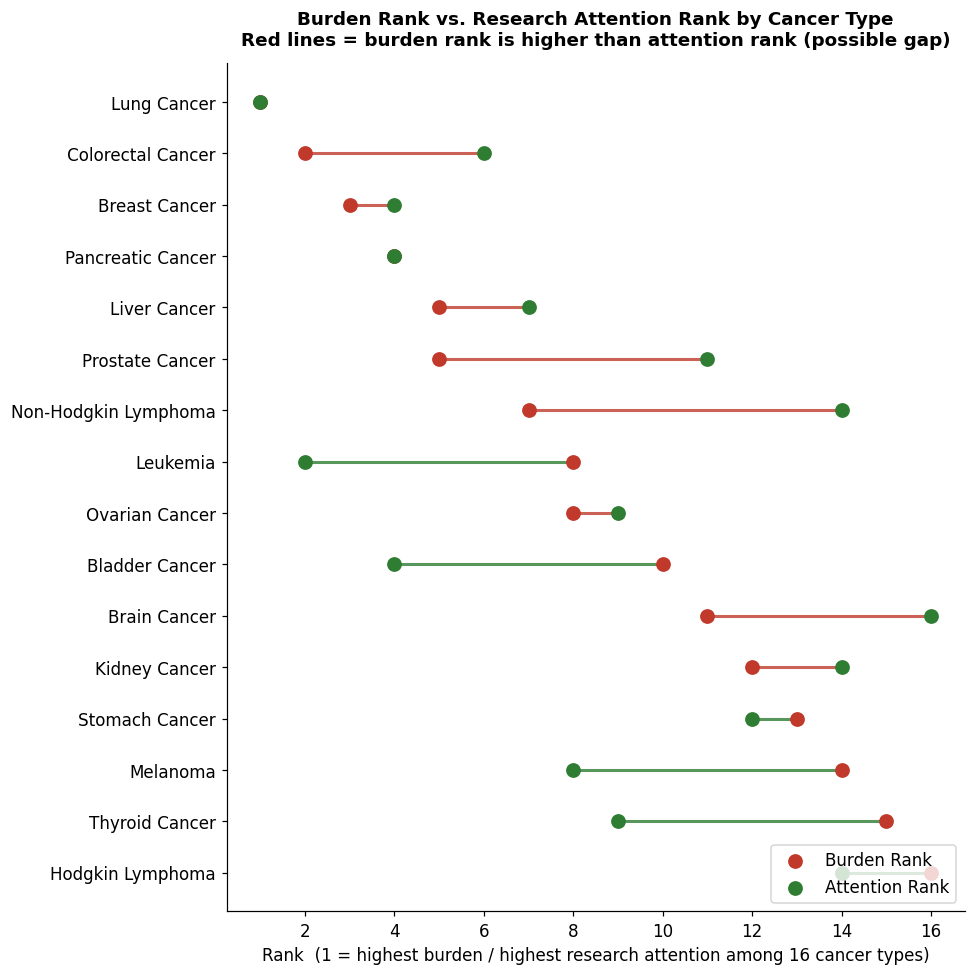

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/04_burden_rank_vs_attention_rank_dumbbell.png

Decision-maker interpretation:
Red lines connect a cancer type's burden rank (left dot) to its attention rank (right dot).
A red line extending to the right means the cancer type is ranked higher for burden than
for research attention — indicating a possible gap. Long red lines are the clearest signals.


In [ ]:
# ============================================================
# Chart 4: Burden Rank vs. Attention Rank Dumbbell Chart
# ============================================================

rank_df = analysis_df.copy()
rank_df["burden_rank"]    = rank_df["burden_score"].rank(ascending=False).astype(int)
rank_df["attention_rank"] = rank_df["research_attention_score"].rank(ascending=False).astype(int)
rank_df = rank_df.sort_values("burden_rank").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 9))

for i, row in enumerate(rank_df.itertuples()):
    gap_color = "#C0392B" if row.burden_rank < row.attention_rank else "#2E7D32"
    ax.plot([row.burden_rank, row.attention_rank], [i, i],
            color=gap_color, linewidth=2, zorder=1, alpha=0.8)
    ax.scatter(row.burden_rank,    i, color="#C0392B", s=75, zorder=2,
               label="Burden Rank" if i == 0 else "")
    ax.scatter(row.attention_rank, i, color="#2E7D32", s=75, zorder=2,
               label="Attention Rank" if i == 0 else "")

ax.set_yticks(range(len(rank_df)))
ax.set_yticklabels(rank_df["cancer_type"])
ax.invert_yaxis()
ax.set_xlabel("Rank  (1 = highest burden / highest research attention among 16 cancer types)")
ax.set_title("Burden Rank vs. Research Attention Rank by Cancer Type\n"
             "Red lines = burden rank is higher than attention rank (possible gap)",
             fontsize=12, fontweight="bold", pad=12)
ax.legend(loc="lower right")

fig.tight_layout()
path = CHART_DIR / "04_burden_rank_vs_attention_rank_dumbbell.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print(f"Saved: {path}")

print("\nDecision-maker interpretation:")
print("Red lines connect a cancer type's burden rank (left dot) to its attention rank (right dot).")
print("A red line extending to the right means the cancer type is ranked higher for burden than")
print("for research attention — indicating a possible gap. Long red lines are the clearest signals.")


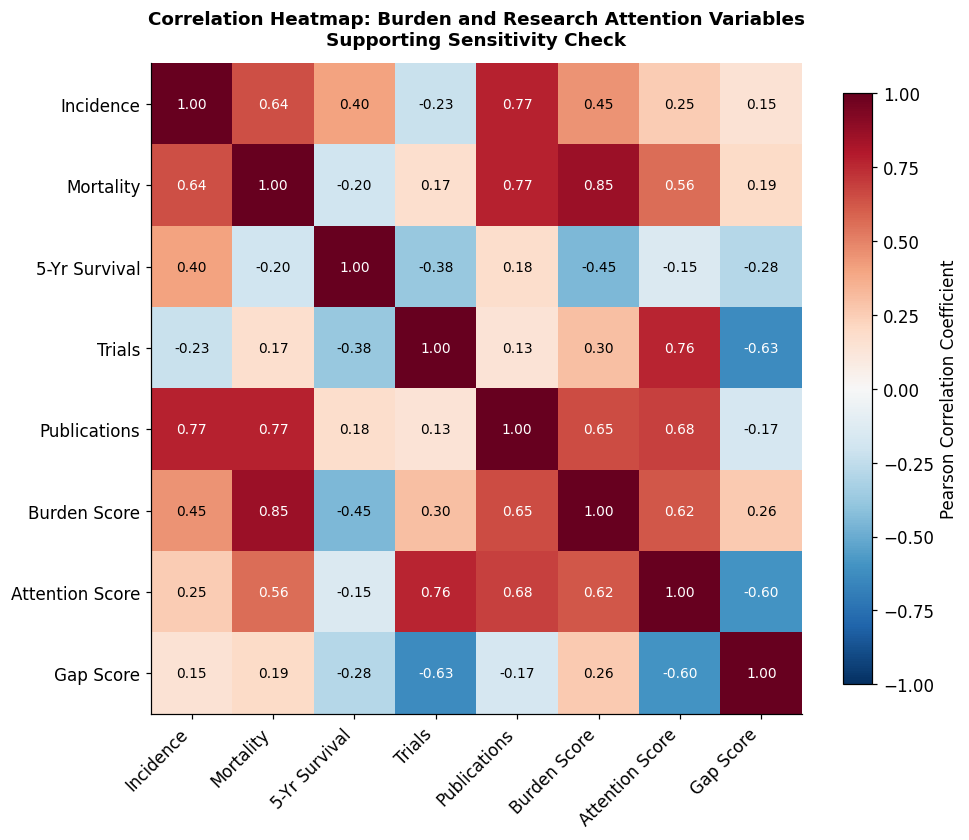

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/05_correlation_heatmap.png

Decision-maker interpretation:
The heatmap shows how strongly the burden and attention variables move together.
Key finding: publications correlate strongly with incidence and mortality (~0.77),
but trial count does not (~0.16 with mortality), confirming that the two research
attention indicators capture different aspects of scientific investment.


In [ ]:
# ============================================================
# Chart 5: Correlation Heatmap (sensitivity check)
# ============================================================

corr_vars = [
    "avg_incidence_rate", "avg_mortality_rate", "avg_five_year_survival_rate",
    "total_trial_count", "total_publication_count",
    "burden_score", "research_attention_score", "attention_gap_score",
]
labels = [
    "Incidence", "Mortality", "5-Yr Survival",
    "Trials", "Publications",
    "Burden Score", "Attention Score", "Gap Score",
]
corr_matrix = analysis_df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="white" if abs(val) > 0.5 else "black", fontsize=9)

fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson Correlation Coefficient")
ax.set_title("Correlation Heatmap: Burden and Research Attention Variables\n"
             "Supporting Sensitivity Check", fontsize=12, fontweight="bold", pad=12)

fig.tight_layout()
path = CHART_DIR / "05_correlation_heatmap.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print(f"Saved: {path}")

print("\nDecision-maker interpretation:")
print("The heatmap shows how strongly the burden and attention variables move together.")
print("Key finding: publications correlate strongly with incidence and mortality (~0.77),")
print("but trial count does not (~0.16 with mortality), confirming that the two research")
print("attention indicators capture different aspects of scientific investment.")


---
## 7. Clustering Analysis

K-means clustering is applied as a **supporting method** to group the 16 cancer types into
interpretable burden-attention profiles. Rather than ranking cancer types on a single score,
clustering reveals which types share similar multivariate characteristics across all eight
features simultaneously — a pattern that may not be fully discernible from a ranked metric alone.

**Approach:**
- Features: incidence rate, mortality rate, five-year survival rate, trial count,
  publication count, burden score, research attention score, and attention gap score.
- All features are standardized (z-score) before clustering to prevent scale dominance.
- K-means is tested for k = 2 to 5. **k = 3 is selected** as the primary solution.
  Although k = 2 produces a marginally higher silhouette score, k = 3 yields a more
  granular and decision-relevant grouping for this analysis.
- Cluster labels are assigned automatically based on whether each cluster's mean burden
  score and mean research attention score are above or below the overall dataset medians.

**Cluster profiles from the executed output:**

| Cluster | Members | Mean Burden | Mean Attention | Mean Gap | Profile summary |
|---|---|---|---|---|---|
| Cluster 0 | Breast Cancer, Prostate Cancer | 0.66 | 0.59 | +0.07 | High-volume cancers; burden modestly exceeds attention |
| Cluster 1 | Brain, Hodgkin Ly., Kidney, Melanoma, Non-Hodgkin Ly., Ovarian, Stomach, Thyroid | 0.37 | 0.35 | +0.02 | Lower-volume cancers with proportionately lower research attention |
| Cluster 2 | Bladder, Colorectal, Leukemia, Liver, Lung, Pancreatic | 0.65 | 0.75 | −0.10 | High-burden cancers attracting substantial or above-burden attention |

**Important caveat on auto-assigned labels:** The labeling function classifies both Cluster 0
and Cluster 2 as "High burden / high attention" because both clusters sit above the dataset
medians on both the burden and attention axes. However, the two clusters are meaningfully
different: Cluster 2 has a notably higher mean attention score (0.75 vs. 0.59) and a negative
mean gap (−0.10 vs. +0.07). Decision-makers should consult the cluster profile table directly
rather than relying on color or auto-assigned labels alone to distinguish these profiles.

**Key insight:** Brain Cancer and Non-Hodgkin Lymphoma — the two cancer types with the
highest composite Attention Gap Scores — both fall within Cluster 1, which groups
lower-volume cancers with proportionately lower research attention. Their elevated gap scores
within this cluster indicate that their research attention is especially low relative to
their burden, even after accounting for their moderate absolute size. Prostate Cancer
appears in Cluster 0 alongside Breast Cancer, reflecting a shared profile of high patient
volume with attention that, while substantial, does not fully keep pace with burden.

In [ ]:
# ============================================================
# 7. K-Means Clustering (k = 3, supporting method)
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_features = [
    "avg_incidence_rate", "avg_mortality_rate", "avg_five_year_survival_rate",
    "total_trial_count", "total_publication_count",
    "burden_score", "research_attention_score", "attention_gap_score",
]

X        = analysis_df[cluster_features].values
X_scaled = StandardScaler().fit_transform(X)

# ── Test k = 2 to 5 ─────────────────────────────────────────────────────────
silhouette_results = []
kmeans_models = {}

for k in [2, 3, 4, 5]:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels)
    silhouette_results.append({"k": k, "silhouette_score": round(score, 4)})
    kmeans_models[k] = (km, labels)

sil_df = pd.DataFrame(silhouette_results)
print("Silhouette scores by k:")
display(sil_df)

# ── Select k = 3 ─────────────────────────────────────────────────────────────
SELECTED_K = 3
km_selected, cluster_labels = kmeans_models[SELECTED_K]
analysis_df["cluster"] = cluster_labels

# ── Profile clusters ──────────────────────────────────────────────────────────
cluster_profile = (
    analysis_df.groupby("cluster")[cluster_features + ["cancer_type"]]
    .agg({**{c: "mean" for c in cluster_features},
          "cancer_type": lambda s: ", ".join(sorted(s))})
    .rename(columns={"cancer_type": "cancer_types_in_cluster"})
    .reset_index()
)

# ── Auto-label clusters ────────────────────────────────────────────────────────
burden_med    = analysis_df["burden_score"].median()
attention_med = analysis_df["research_attention_score"].median()

def label_cluster(row):
    high_burden    = row["burden_score"]             >= burden_med
    high_attention = row["research_attention_score"] >= attention_med
    if high_burden and high_attention:
        return "High burden / high attention"
    elif high_burden and not high_attention:
        return "High burden / lower attention"
    elif not high_burden and high_attention:
        return "Lower burden / high attention"
    else:
        return "Lower burden / lower attention"

cluster_profile["cluster_label"] = cluster_profile.apply(label_cluster, axis=1)
label_map = dict(zip(cluster_profile["cluster"], cluster_profile["cluster_label"]))
analysis_df["cluster_label"] = analysis_df["cluster"].map(label_map)

display(cluster_profile[["cluster","cluster_label","burden_score",
                          "research_attention_score","attention_gap_score",
                          "cancer_types_in_cluster"]])

# ── Save cluster profile ──────────────────────────────────────────────────────
cluster_path = TABLE_DIR / "cluster_profile_summary.csv"
cluster_profile.to_csv(cluster_path, index=False)
print(f"Saved: {cluster_path}")


Silhouette scores by k:


,k,silhouette_score
0,2,0.304
1,3,0.268
2,4,0.273
3,5,0.242


,cluster,cluster_label,burden_score,research_attention_score,attention_gap_score,cancer_types_in_cluster
0,0,High burden / high attention,0.656,0.586,0.070,"Breast Cancer, Prostate Cancer"
1,1,Lower burden / lower attention,0.370,0.352,0.018,"Brain Cancer, Hodgkin Lymphoma, Kidney Cancer,..."
2,2,High burden / high attention,0.649,0.753,-0.103,"Bladder Cancer, Colorectal Cancer, Leukemia, L..."


Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Tables/cluster_profile_summary.csv


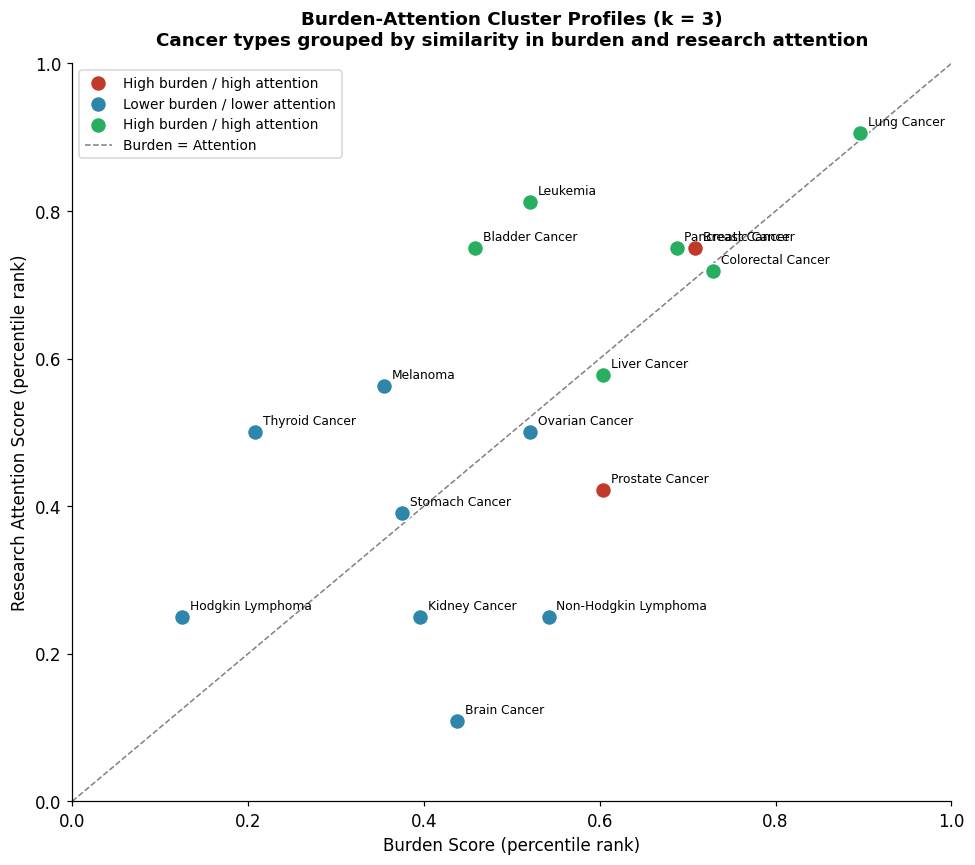

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/06_cluster_burden_vs_attention.png

Decision-maker interpretation:
Cancer types in the same cluster share a similar overall burden-attention profile.
Cluster interpretation should be based on the cluster profile table, not color alone.
The clusters are used as a supporting method to summarize patterns, not as a standalone funding rule.


In [ ]:
# ============================================================
# Chart 6: Cluster Scatter — Burden vs. Attention by Cluster
# ============================================================

CLUSTER_COLORS = {0: "#C0392B", 1: "#2E86AB", 2: "#27AE60", 3: "#8E44AD"}

fig, ax = plt.subplots(figsize=(9, 8))

for c in sorted(analysis_df["cluster"].unique()):
    subset = analysis_df[analysis_df["cluster"] == c]
    label  = label_map.get(c, f"Cluster {c}")
    ax.scatter(subset["burden_score"], subset["research_attention_score"],
               s=110, color=CLUSTER_COLORS.get(c, "gray"),
               edgecolor="white", zorder=3, label=label)
    for _, row in subset.iterrows():
        ax.annotate(row["cancer_type"],
                    (row["burden_score"], row["research_attention_score"]),
                    fontsize=8, xytext=(5, 5), textcoords="offset points")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Burden = Attention")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("Burden Score (percentile rank)")
ax.set_ylabel("Research Attention Score (percentile rank)")
ax.set_title(f"Burden-Attention Cluster Profiles (k = {SELECTED_K})\n"
             "Cancer types grouped by similarity in burden and research attention",
             fontsize=12, fontweight="bold", pad=12)
ax.legend(fontsize=9, loc="upper left")

fig.tight_layout()
path = CHART_DIR / "06_cluster_burden_vs_attention.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print(f"Saved: {path}")

print("\nDecision-maker interpretation:")
print("Cancer types in the same cluster share a similar overall burden-attention profile.")
print("Cluster interpretation should be based on the cluster profile table, not color alone.")
print("The clusters are used as a supporting method to summarize patterns, not as a standalone funding rule.")


---
## 8. NLP / TF-IDF Theme Exploration

Where sufficient text from trial summaries or publication abstracts is available, TF-IDF
(Term Frequency–Inverse Document Frequency) is used to identify the dominant research themes
associated with each cancer type. This section focuses on the cancer types most flagged by
the composite Attention Gap Score, as these are the cases where theme-level context is most
decision-relevant.

**Important:** NLP is applied here to characterize research themes, not to measure research
quality, depth, or outcomes. Results are reported only where the available text volume
supports reliable term weighting. Where text is insufficient, this method is documented as
considered but not carried forward into the final report.

In [ ]:
# ============================================================
# 8. TF-IDF Theme Exploration
# ============================================================

import re
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

CUSTOM_STOPWORDS = {
    "cancer", "cancers", "patient", "patients", "treatment", "treatments",
    "trial", "trials", "study", "studies", "clinical", "therapy", "therapies",
    "disease", "diseases", "tumor", "tumors", "tumour", "tumours", "cell", "cells",
}
ALL_STOPWORDS = list(ENGLISH_STOP_WORDS.union(CUSTOM_STOPWORDS))

TEXT_COL_PRIORITY = ["combined_text_sample", "publication_text_sample", "trial_text_sample"]
text_col = next((c for c in TEXT_COL_PRIORITY if c in analysis_df.columns), None)
MIN_AVG_WORDS = 20
nlp_ran = False

if text_col is None:
    print("No text columns found in analysis_df. NLP section skipped.")
    print("This section was considered but not carried forward due to limited text availability.")
else:
    def clean_text(t):
        t = str(t).lower()
        t = re.sub(r"[^a-z\s]", " ", t)
        return re.sub(r"\s+", " ", t).strip()

    analysis_df["clean_text"] = analysis_df[text_col].fillna("").apply(clean_text)
    avg_words = analysis_df["clean_text"].str.split().apply(len).mean()
    print(f"Text column used : {text_col}")
    print(f"Avg words/cancer : {avg_words:.1f}")

    if avg_words < MIN_AVG_WORDS or analysis_df["clean_text"].str.strip().eq("").all():
        print("\nText volume is too sparse for reliable TF-IDF weighting.")
        print("NLP was considered but is not carried forward into the final report.")
    else:
        nlp_ran = True
        vectorizer   = TfidfVectorizer(stop_words=ALL_STOPWORDS, max_features=500, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(analysis_df["clean_text"])
        terms        = np.array(vectorizer.get_feature_names_out())

        records = []
        for i, cancer in enumerate(analysis_df["cancer_type"]):
            row_vec  = tfidf_matrix[i].toarray().flatten()
            top_idx  = row_vec.argsort()[::-1][:10]
            records.append({"cancer_type": cancer, "top_terms": ", ".join(terms[top_idx])})

        top_terms_df = pd.DataFrame(records)

        # Focus on the most under-attended types for reporting
        under_attended_types = (
            analysis_df
            .sort_values("attention_gap_score", ascending=False)
            .head(5)["cancer_type"]
            .tolist()
        )
        selected_terms_df = top_terms_df[top_terms_df["cancer_type"].isin(under_attended_types)]
        display(selected_terms_df)

        tfidf_path = TABLE_DIR / "tfidf_top_terms_selected_cancers.csv"
        selected_terms_df.to_csv(tfidf_path, index=False)
        print(f"Saved: {tfidf_path}")


Text column used : combined_text_sample
Avg words/cancer : 701.9


,cancer_type,top_terms
1,Brain Cancer,"brain, opn, bbb, metastasis, glioma, macrophag..."
5,Kidney Cancer,"rcc, kidney, renal, factors, risk, carcinoma, ..."
7,Liver Cancer,"liver, limore, transcriptomic, landscape, hepa..."
10,Non-Hodgkin Lymphoma,"lymphoma, br, chop, cvp, fl, rituximab, aspen,..."
13,Prostate Cancer,"prostate, rehit, intervention, mcrpc, men, car..."


Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Tables/tfidf_top_terms_selected_cancers.csv


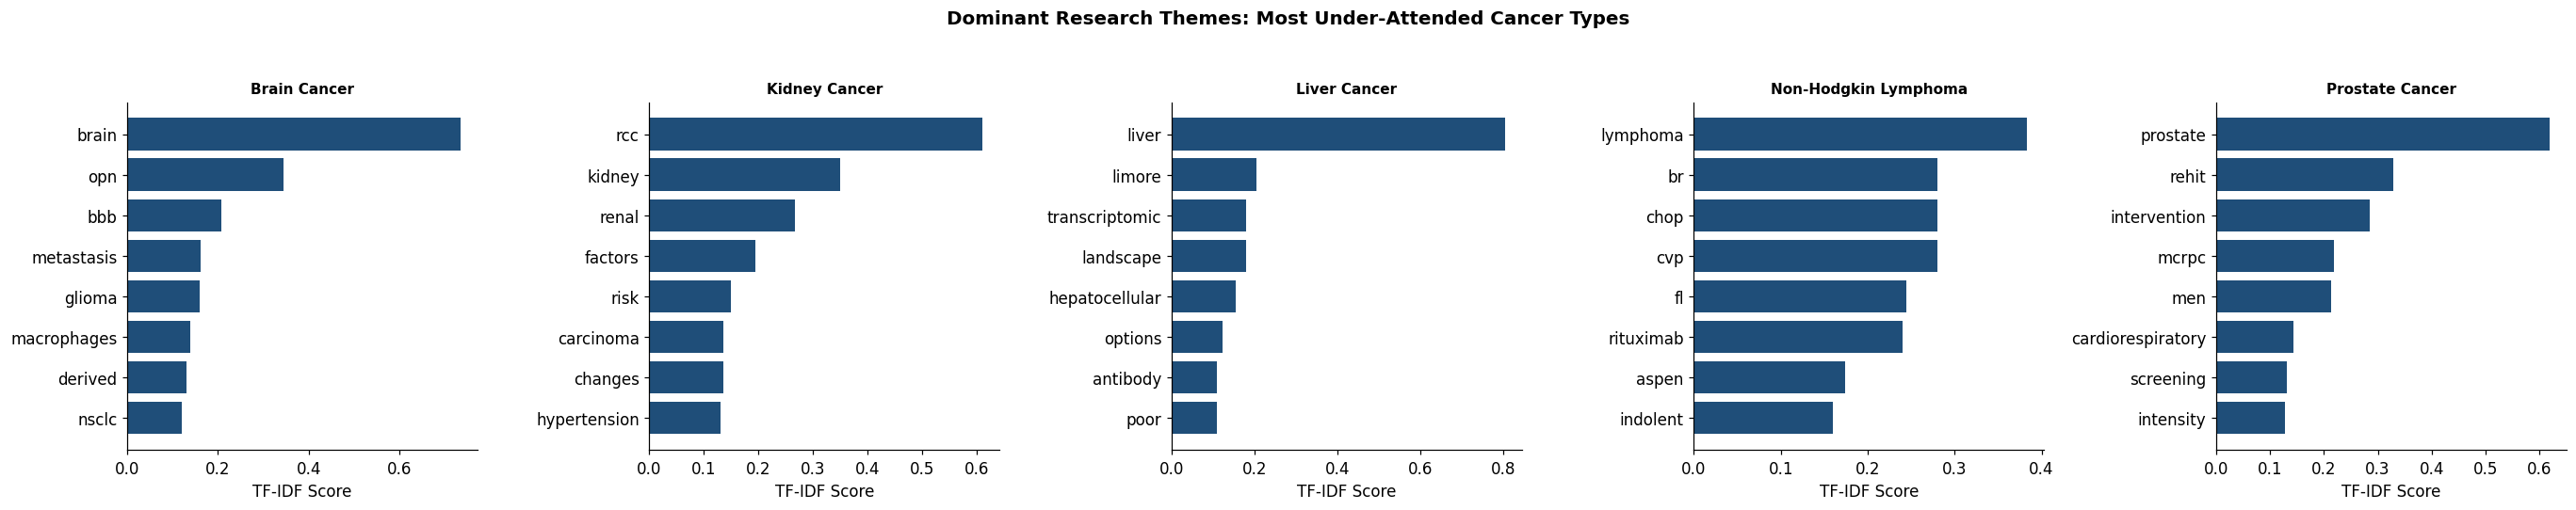

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/07_tfidf_terms_under_attended.png


In [ ]:
# ============================================================
# Chart 7: Top TF-IDF Terms for Most Under-Attended Cancer Types
# ============================================================

if nlp_ran:
    under_df = analysis_df[analysis_df["cancer_type"].isin(under_attended_types)]
    n_panels = len(under_df)

    fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5))
    if n_panels == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, under_df.iterrows()):
        idx      = analysis_df.index[analysis_df["cancer_type"] == row["cancer_type"]][0]
        tfidf_row = tfidf_matrix[idx].toarray().flatten()
        top_idx   = tfidf_row.argsort()[::-1][:8]
        ax.barh(terms[top_idx][::-1], tfidf_row[top_idx][::-1], color="#1F4E79")
        ax.set_title(row["cancer_type"], fontsize=10)
        ax.set_xlabel("TF-IDF Score")

    fig.suptitle("Dominant Research Themes: Most Under-Attended Cancer Types",
                 fontsize=13, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.94])

    path = CHART_DIR / "07_tfidf_terms_under_attended.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")
else:
    print("Chart 7 skipped: insufficient text for TF-IDF analysis.")


---
## 9. Final Analytical Takeaways

> ***Are cancer research resources aligned with the burden of disease?***

---

### Primary Finding

The Composite Attention Gap Score reveals clear stratification across the 16 cancer types.
**Brain Cancer (+0.33) and Non-Hodgkin Lymphoma (+0.29)** show the largest positive gaps,
placing them in the *potentially under-attended* category and earning the highest-priority
review designation in the decision-maker review table. These two cancer types stand out as
the most salient cases where measured disease burden appears less commensurate with
research attention.

**Prostate Cancer (+0.18)** and **Kidney Cancer (+0.15)** are *moderately under-attended*,
each assigned a medium-priority review designation. Their gaps are meaningful but less
pronounced, and their component-level profiles warrant careful interpretation before drawing
conclusions about the nature of any potential misalignment.

Lung Cancer (−0.01), Pancreatic Cancer (−0.06), and Breast Cancer (−0.04) fall in the
relatively balanced or higher-attention range in the current analysis. Moreover, despite
Lung Cancer carrying the highest mortality rate in the dataset (31.5 per 100,000), it also
attracts the highest trial count (94) and the highest publication count (79,441) — producing
a research attention score that is broadly proportionate to its burden at the relative scale
used here.

---

### Component-Level Evidence

The component-level checks provide a nuanced view of the findings. A cancer type showing
positive gaps across all three components — incidence, mortality, and survival — offers
more robust evidence of possible misalignment than one that appears under-attended on
a single component alone.

- **Brain Cancer** shows positive gaps on the mortality (+0.33) and survival (+0.64)
  components, reflecting its poor five-year survival rate (34.7%). Its incidence gap is near
  zero, indicating the gap is driven by severity rather than patient volume.
- **Non-Hodgkin Lymphoma** shows positive gaps across all three components — incidence (+0.44),
  mortality (+0.25), and survival (+0.19) — making it the most cross-component-consistent
  finding in the dataset. This consistency corroborates the strength of its composite ranking
  and supports its high-priority review designation.
- **Prostate Cancer** shows strong positive gaps on incidence (+0.52) and mortality (+0.45),
  but a negative survival gap (−0.42), driven by its very high five-year survival rate (99%).
  Accordingly, its composite gap reflects volume burden rather than poor prognosis — a
  decision-relevant distinction when determining what form of review is appropriate.
- **Kidney Cancer** shows modest positive gaps across all three components (incidence: +0.31,
  mortality: +0.06, survival: +0.06), indicating a mild but consistent signal.
- **Lung Cancer** shows near-zero component gaps despite its high mortality burden,
  confirming that its substantial research activity is broadly commensurate with its
  disease profile at the relative scale of this analysis.

---

### Supporting Clustering Evidence

K-means clustering (k = 3) groups the 16 cancer types into three profiles that corroborate
the composite score findings through an independent analytical method:

- **Cluster 0** (Breast Cancer, Prostate Cancer): High-volume cancers with substantial
  but modestly under-proportionate attention (mean gap: +0.07).
- **Cluster 1** (Brain, Non-Hodgkin Lymphoma, Kidney, Melanoma, Ovarian, Stomach, Thyroid,
  Hodgkin Lymphoma): Lower-volume cancers with proportionately lower research attention
  (mean gap: +0.02). Brain Cancer and Non-Hodgkin Lymphoma — the two highest-gap cancer types
  — appear here, indicating that their attention is especially low relative to even their
  moderate burden levels.
- **Cluster 2** (Lung, Colorectal, Bladder, Leukemia, Liver, Pancreatic): High-burden
  cancers attracting substantial research attention, with a mean gap of −0.10.

However, the auto-labeling logic assigns both Cluster 0 and Cluster 2 the label
"High burden / high attention," as both fall above the dataset medians on both axes.
Decision-makers should consult the cluster profile table directly for the full numeric profiles,
rather than relying on cluster labels alone.

---

### Inverse Pattern

Thyroid Cancer (−0.29), Bladder Cancer (−0.29), and Leukemia (−0.29) show the most negative
attention gap scores, indicating research attention that substantially meets or exceeds their
measured burden. Thyroid Cancer — with a five-year survival rate of 98.2% and a mortality
rate of only 0.50 per 100,000 — generates disproportionately high publication and trial counts
relative to its burden profile. These cancer types may serve as useful reference points for
what well-attended or over-attended research profiles look like within this dataset.

---

### What This Analysis Does Not Claim

- This analysis does not conclude that any cancer type is definitively underfunded or neglected.
- It does not evaluate research quality, treatment outcomes, innovation timelines, or patient access.
- Positive Attention Gap Scores are signals for closer expert review, not directives for
  automatic resource reallocation.
- All scores are relative to this 16-cancer dataset and do not represent absolute judgments
  of research adequacy.

---

### Recommended Use

This framework is designed to support evidence-based prioritization discussions.
Decision-makers should use the ranked summary table and the decision-maker review table
as a structured screening tool — a judicious first filter for identifying cancer types that
may warrant more detailed expert investigation, supplemented by clinical expertise, funding
data, and knowledge of the current research pipeline.

---

> **Interpretation note:** The Attention Gap Score is a relative screening metric based on
> publication and trial-count proxies. It is designed to identify cancer types that may warrant
> closer expert review, not to make definitive claims about underfunding or research quality.
> Full limitations and references are provided in the final written report.

---
## 10. Conclusion

In summary, this study establishes an interpretable, empirical framework to evaluate whether scientific research attention aligns with epidemiological disease burden across 16 major cancer types. By integrating epidemiological parameters from SEER, clinical trial registries from ClinicalTrials.gov, and publication metrics from PubMed—and applying percentile-rank normalization, component-level disaggregation, and supportive $K$-means clustering—the model generates a Composite Attention Gap Score that facilitates systematic, decision-relevant comparisons between research focus and disease impact.

**Findings from the current analysis:**

- **Brain Cancer (+0.33) and Non-Hodgkin Lymphoma (+0.29)** show the strongest positive
  Attention Gap Scores and may accordingly warrant closer expert review. Notably, Non-Hodgkin
  Lymphoma shows positive gaps across all three burden components — incidence, mortality, and
  survival — making it the most cross-component-consistent finding in the dataset.
- **Prostate Cancer (+0.18) and Kidney Cancer (+0.15)** show moderate positive gaps and
  may merit continued monitoring or secondary review. Prostate Cancer's gap is driven primarily
  by high incidence and mortality volume rather than poor prognosis, given its very high
  five-year survival rate (99%).
- **Lung Cancer and Pancreatic Cancer** appear relatively balanced or higher-attention in the
  current output. Despite their high mortality burdens, both attract substantial research
  activity in absolute terms — resulting in attention scores that are broadly proportionate
  to their burden at the relative scale of this analysis.
- **Thyroid Cancer, Bladder Cancer, and Leukemia** (each at −0.29) show the most negative
  gap scores, with research attention that substantially meets or exceeds their measured burden.
  In contrast to the high-gap cancers, these types may serve as useful reference points for
  what well-attended research profiles look like.

**Implementation Guide:**

Synthesizing the Composite Attention Gap Score, component-level evaluations, and clustering outputs yields consistent evidence of potential disparities between disease burden and research attention. Nevertheless, these insights constitute advisory signals rather than prescriptive funding benchmarks. The associated review tables are intended to operate as a preliminary diagnostic tool, offering a systematic first-stage filter to identify cancer types requiring targeted expert examination

Any funding or policy decision should consequently be supplemented by:

- Clinical and scientific expertise regarding each cancer type's research landscape
- Direct research funding data and industry investment records
- Research pipeline maturity and trial feasibility assessments
- Subtype-level analysis, as broad cancer categories may conceal important heterogeneity
- Patient access considerations and demographic equity data

---

